In [1]:
from google.colab import files
uploaded = files.upload()

Saving sleep_study_1000.csv to sleep_study_1000.csv


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
df = pd.read_csv(list(uploaded.keys())[0])

display(df)

print("\nDataset Info:")
df.info()

,ID,Age,Gender,Bedtime,WakeupTime,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,SmokingStatus,ExerciseFrequency
0,1,80,Female,2025-09-30 07:32:17,2025-09-30 13:49:16.669051,6.283241,0.57,15,35,50,0,25.0,1,Yes,1
1,2,24,Male,2025-06-29 20:59:50,2025-06-30 04:09:10.207162,7.155613,0.91,29,68,3,4,50.0,0,No,2
2,3,37,Male,2025-12-24 21:28:32,2025-12-25 03:31:34.257053,6.050627,0.58,15,35,50,3,50.0,0,No,5
3,4,68,Female,2025-02-22 00:25:33,2025-02-22 07:26:37.046703,7.017791,0.88,28,44,28,1,50.0,0,Yes,4
4,5,58,Male,2025-09-02 12:31:53,2025-09-02 21:17:46.256228,8.764793,0.95,28,40,32,4,25.0,4,No,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,30,Female,2025-05-16 16:24:49,2025-05-16 23:01:38.331733,6.613703,0.92,21,53,26,4,NaN,2,Yes,5
996,997,80,Male,2025-11-11 03:05:18,2025-11-11 09:13:14.413227,6.132337,0.53,16,50,34,3,50.0,3,Yes,3
997,998,77,Female,2025-02-19 03:35:34,2025-02-19 11:50:19.392085,8.245942,0.84,27,58,15,1,NaN,5,No,4
998,999,57,Male,2025-06-28 19:33:34,2025-06-29 01:45:24.810472,6.197447,0.66,29,44,27,4,NaN,1,No,4



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1000 non-null   int64  
 1   Age                   1000 non-null   int64  
 2   Gender                1000 non-null   object 
 3   Bedtime               1000 non-null   object 
 4   WakeupTime            1000 non-null   object 
 5   SleepDuration         1000 non-null   float64
 6   SleepEfficiency       1000 non-null   float64
 7   REMSleepPercentage    1000 non-null   int64  
 8   DeepSleepPercentage   1000 non-null   int64  
 9   LightSleepPercentage  1000 non-null   int64  
 10  Awakenings            1000 non-null   int64  
 11  CaffeineConsumption   744 non-null    float64
 12  AlcoholConsumption    1000 non-null   int64  
 13  SmokingStatus         1000 non-null   object 
 14  ExerciseFrequency     1000 non-null   int64  
dtypes: floa

In [39]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID                        0
Age                       0
Gender                    0
Bedtime                   0
WakeupTime                0
SleepDuration             0
SleepEfficiency           0
REMSleepPercentage        0
DeepSleepPercentage       0
LightSleepPercentage      0
Awakenings                0
CaffeineConsumption     256
AlcoholConsumption        0
SmokingStatus             0
ExerciseFrequency         0
dtype: int64


In [40]:
df = df.dropna()

In [41]:
le = LabelEncoder() #convert object to numerical data[male,female=0,1]

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [42]:
df

,ID,Age,Gender,Bedtime,WakeupTime,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,SmokingStatus,ExerciseFrequency
0,1,80,0,517,517,6.283241,0.57,15,35,50,0,25.0,1,1,1
1,2,24,1,343,343,7.155613,0.91,29,68,3,4,50.0,0,0,2
2,3,37,1,701,701,6.050627,0.58,15,35,50,3,50.0,0,0,5
3,4,68,0,86,86,7.017791,0.88,28,44,28,1,50.0,0,1,4
4,5,58,1,461,461,8.764793,0.95,28,40,32,4,25.0,4,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,21,0,156,156,8.639963,0.53,29,32,39,1,50.0,4,1,4
991,992,24,0,706,706,8.291486,0.74,18,55,27,5,50.0,2,1,1
993,994,65,0,551,551,5.160813,0.76,18,60,22,0,0.0,0,1,3
996,997,80,1,604,603,6.132337,0.53,16,50,34,3,50.0,3,1,3


In [43]:
target_column = "SleepEfficiency"

X = df.drop(target_column, axis=1) #what we use to predict
y = df[target_column] #what you want to predict

print("Target Column:", target_column)

Target Column: SleepEfficiency


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
df

,ID,Age,Gender,Bedtime,WakeupTime,SleepDuration,SleepEfficiency,REMSleepPercentage,DeepSleepPercentage,LightSleepPercentage,Awakenings,CaffeineConsumption,AlcoholConsumption,SmokingStatus,ExerciseFrequency
0,1,80,0,517,517,6.283241,0.57,15,35,50,0,25.0,1,1,1
1,2,24,1,343,343,7.155613,0.91,29,68,3,4,50.0,0,0,2
2,3,37,1,701,701,6.050627,0.58,15,35,50,3,50.0,0,0,5
3,4,68,0,86,86,7.017791,0.88,28,44,28,1,50.0,0,1,4
4,5,58,1,461,461,8.764793,0.95,28,40,32,4,25.0,4,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,21,0,156,156,8.639963,0.53,29,32,39,1,50.0,4,1,4
991,992,24,0,706,706,8.291486,0.74,18,55,27,5,50.0,2,1,1
993,994,65,0,551,551,5.160813,0.76,18,60,22,0,0.0,0,1,3
996,997,80,1,604,603,6.132337,0.53,16,50,34,3,50.0,3,1,3


In [25]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression:
MAE: 0.11303511031324984
MSE: 0.0169884433854017
R2: -0.017875772660915557


Cannot capture relationship properly
Underfitting (too simple)
Not suitable for this dataset

In [26]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree:
MAE: 0.14315436241610738
MSE: 0.03242885906040268
R2: -0.9430002634016372


In [27]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest:
MAE: 0.11744496644295303
MSE: 0.018013726644295302
R2: -0.07930641499035973


In [28]:
svr = SVR()
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

print("SVR:")
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("R2:", r2_score(y_test, y_pred_svr))

SVR:
MAE: 0.12428475723639651
MSE: 0.022042058767431073
R2: -0.3206670611279021


In [29]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "SVR"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_svr)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_svr)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_svr)
    ]
})

display(results)

,Model,MAE,MSE,R2 Score
0,Linear Regression,0.113035,0.016988,-0.017876
1,Decision Tree,0.143154,0.032429,-0.943000
2,Random Forest,0.117445,0.018014,-0.079306
3,SVR,0.124285,0.022042,-0.320667


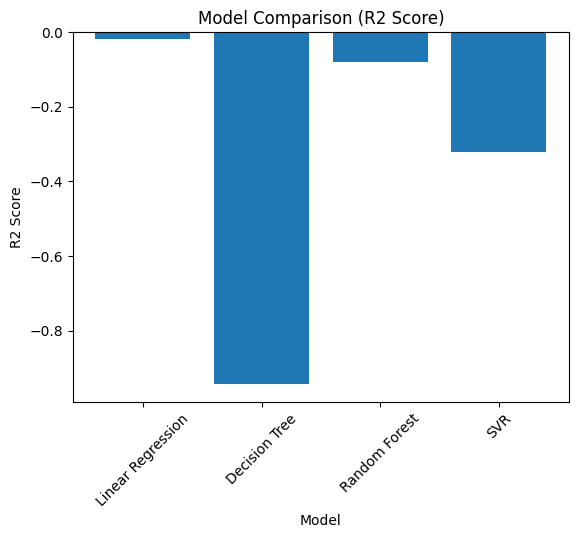

In [30]:
plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()

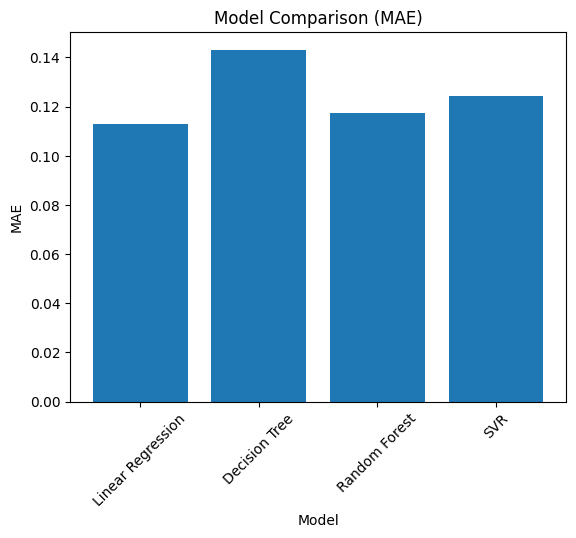

In [31]:
plt.figure()
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

In [32]:
best_model = results.sort_values(by="R2 Score", ascending=False)
print("Best Model:")
display(best_model.head(1))

Best Model:


,Model,MAE,MSE,R2 Score
0,Linear Regression,0.113035,0.016988,-0.017876


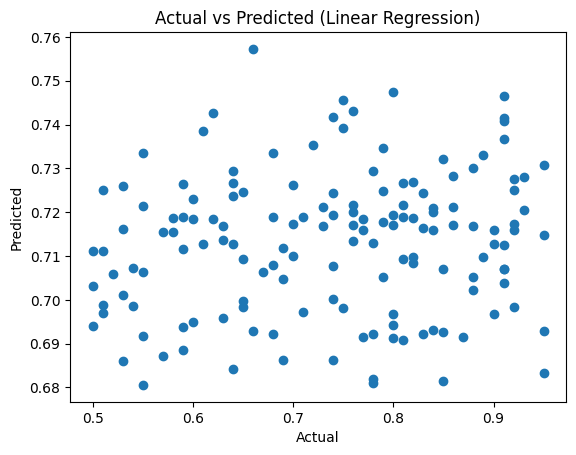

In [33]:
best_name = best_model.iloc[0]["Model"]

if best_name == "Linear Regression":
    y_best = y_pred_lr
elif best_name == "Decision Tree":
    y_best = y_pred_dt
elif best_name == "Random Forest":
    y_best = y_pred_rf
else:
    y_best = y_pred_svr

plt.figure()
plt.scatter(y_test, y_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_name})")
plt.show()

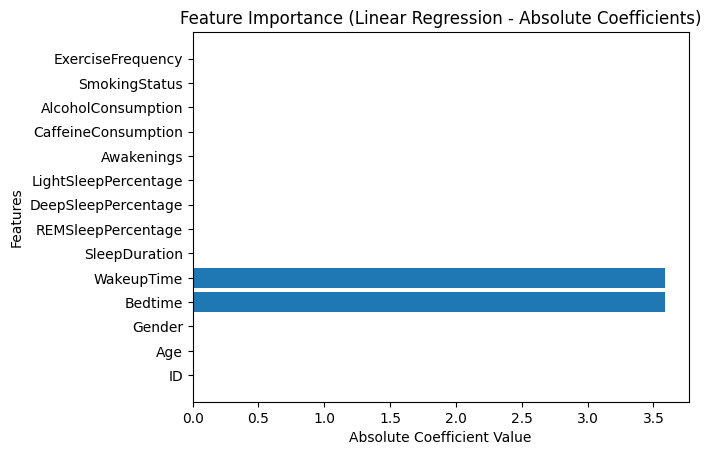

In [63]:
importances = lr.coef_

plt.figure()
plt.barh(X.columns, abs(importances))
plt.title("Feature Importance (Linear Regression - Absolute Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Features")
plt.show()

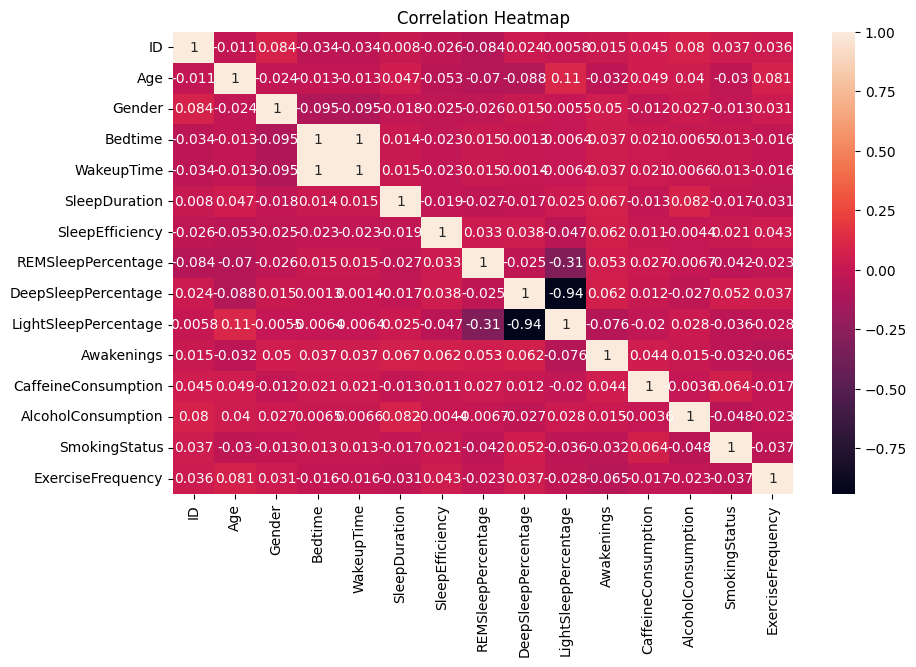

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

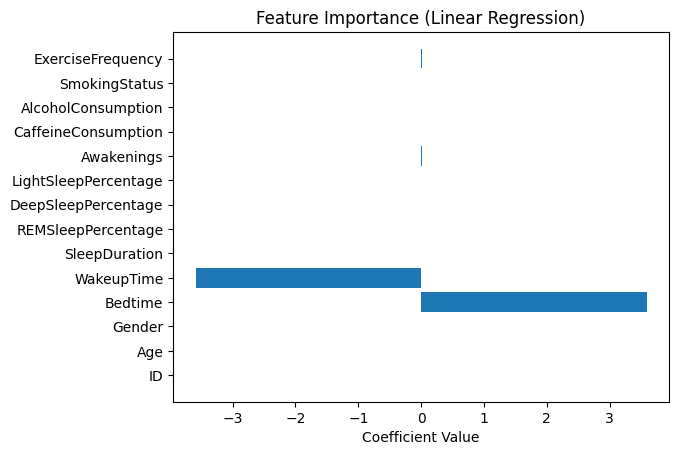

In [61]:
importances = lr.coef_

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.show()

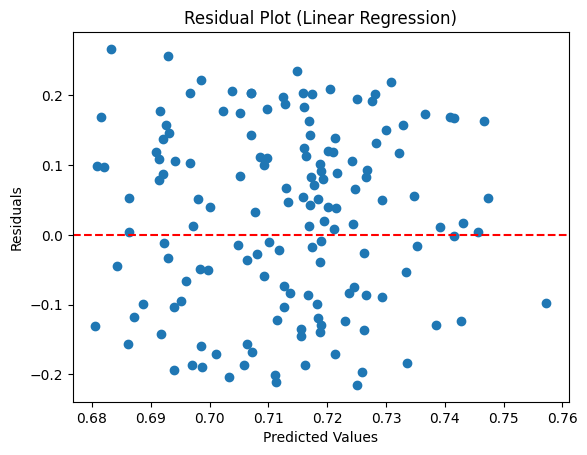

In [64]:
residuals = y_test - y_pred_lr

plt.figure()
plt.scatter(y_pred_lr, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot (Linear Regression)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

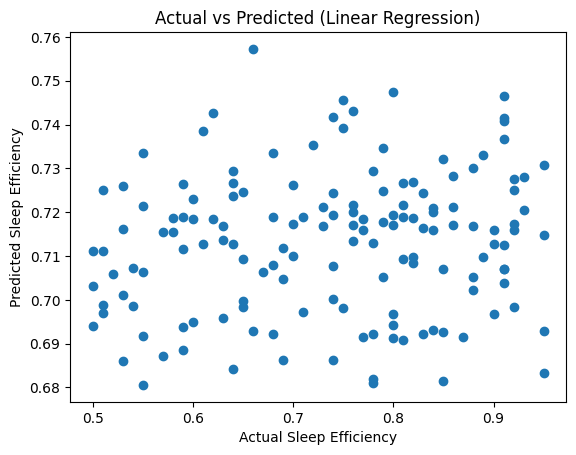

In [56]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Sleep Efficiency")
plt.ylabel("Predicted Sleep Efficiency")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

“How close are predictions to real values?” - actual vs predicted plot

“Are errors random or is there a pattern?” - residual plot